In [59]:
import glob
import os
from multiprocessing import Pool
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from mpl_toolkits.axes_grid1 import make_axes_locatable
from datetime import datetime
from tqdm import tqdm
import pandas as pd
from utils.data_loader import RainfallDataLoader
import plotly.io as pio
import pickle
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import Holt
# from statsmodels.tsa.holtwinters import hol
from statsmodels.tsa.arima.model import ARIMA
# from codecarbon import track_emissions
# from cycler import cycler
from utils.vizualizations import plot_bias_using_QQ_plot

In [2]:
# Set global dark mode
pio.templates.default = 'plotly_dark'

plt.rcParams['image.cmap'] = 'viridis' 
# Set global color cycle
# colors = plt.colormaps['tab10'].resampled(10)(range(10))
# plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# plt.style.use("dark_background")

In [1]:
from shapely.geometry import Polygon
from pyproj import Geod

# Coordinates (lon, lat)
uttarakhand_coords = [
    [77.8, 31.9],
    [81.0, 31.9],
    [81.0, 28.75],
    [77.8, 28.75]
]

# Create a polygon
polygon = Polygon(uttarakhand_coords)

# Define geodesic calculator (WGS84 ellipsoid)
geod = Geod(ellps="WGS84")

# Calculate area (m^2)
area, _ = geod.geometry_area_perimeter(polygon)

# Convert to square kilometers (area is negative if polygon vertices are in clockwise order)
area_km2 = abs(area) / 1e6

print(f"Approximate area of Uttarakhand region: {area_km2:.2f} sq. km")


Approximate area of Uttarakhand region: 107458.48 sq. km


In [3]:
import numpy as np
from pyproj import Geod

# Define the coordinates (Longitude, Latitude)
uttarakhand_coords = [
    [77.8, 31.9],
    [81.0, 31.9],
    [81.0, 28.75],
    [77.8, 28.75]
]

# Close the polygon by appending the first point at the end
coords = np.array(uttarakhand_coords + [uttarakhand_coords[0]])

lons = coords[:, 0]
lats = coords[:, 1]

# Use the Geodesic area calculation from pyproj (most accurate for lat/lon)
geod = Geod(ellps="WGS84")
area_m2, _ = geod.polygon_area_perimeter(lons, lats)

# Convert to square kilometers
area_km2 = abs(area_m2) / 1e6

print(f"Area enclosed by the polygon: {area_km2:,.2f} km²")

Area enclosed by the polygon: 107,458.48 km²


## Loading Dataset
For reprojection I need reference cooridinate system. I am loading one CHIRPS .tif file to extract its transform and other attributes, which are necessary to reproject ERA5, by doing this way I saving memory and I am able to use multiprocessing for faster load times as compared to earllier method which did everything in sequential order.

In [3]:
rainfall_data_loader = RainfallDataLoader()

In [4]:
chirps_data_dict = rainfall_data_loader.get_chirps_data()
chirps_dates = list(chirps_data_dict.keys())
chirps_dataset = list(chirps_data_dict.values())
chirps_dates = np.array(chirps_dates)
chirps_dataset = np.array(chirps_dataset)

Loading CHIRPS Data: 100%|██████████| 16314/16314 [00:04<00:00, 3880.00it/s]


In [5]:
original_era5_data_dict, reprojected_era5_data_dict = rainfall_data_loader.get_era5_data()

era5_dates = list(original_era5_data_dict.keys())
original_era5_dataset = list(original_era5_data_dict.values())
reprojected_era5_dataset = list(reprojected_era5_data_dict.values())
era5_dates = np.array(era5_dates)
original_era5_dataset = np.array(original_era5_dataset)
reprojected_era5_dataset = np.array(reprojected_era5_dataset)

Loading ERA5 Data: 100%|██████████| 14435/14435 [00:00<00:00, 13636211.32it/s]


In [6]:
original_era5_dataset.shape

(14435, 5, 13, 13)

In [7]:
# file = '../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-01-01.tif'
# ref = rasterio.open(file)

In [8]:
# CHIRPS_GEOTIFF_DIR = '../../CHIRPS_daily_Uttarakhand'
# ERA5_GEOTIFF_DIR = '../../ERA5_daily_Uttarakhand'

# def reproject_era5(ref, src, channel):
#     reprojection = np.empty(ref.shape, dtype=ref.dtypes[0])
#     reproject(
#         source=rasterio.band(src, channel),
#         destination=reprojection,
#         src_transform=src.transform,
#         src_crs=src.crs,
#         dst_transform=ref.transform,
#         dst_crs=ref.crs,
#         dst_nodata=ref.nodata,
#         resampling=Resampling.cubic
#     )
#     return reprojection


# # @track_emissions()
# def load_chirps_geotiff(file_path):
#     try:
#         filename = os.path.basename(file_path)
#         date_str = filename.split("_")[-1].replace(".tif", "")
#         date_key = datetime.strptime(date_str, "%Y-%m-%d").date()
#         with rasterio.open(file_path) as src:
#             data = src.read(1)
#         return date_key, data, file_path
#     except Exception as e:
#         print(f"Failed to load {file_path}: {e}")
#         return None, None, file_path
        
# # @track_emissions()
# def load_era5_geotiff(file_path):
#     try:
#         filename = os.path.basename(file_path)
#         date_str = filename.split("_")[-1].replace(".tif", "")
#         date_key = datetime.strptime(date_str, "%Y-%m-%d").date()
#         with rasterio.open(file_path) as src:
#             air_temperature = reproject_era5(ref=ref, src=src, channel=1)
#             dewpoint_temperature = reproject_era5(ref=ref, src=src, channel=4)
#             total_precpitation = reproject_era5(ref=ref, src=src, channel=5)
#             u_wind = reproject_era5(ref=ref, src=src, channel=8)
#             v_wind = reproject_era5(ref=ref, src=src, channel=9)
#             reprojected_era5 = np.stack(
#                 (
#                     air_temperature,
#                     dewpoint_temperature,
#                     total_precpitation*1000,
#                     u_wind,
#                     v_wind
#                 )
#             )
#             original_era5 = np.stack(
#                 (
#                     src.read(1),
#                     src.read(4),
#                     src.read(5)*1000,
#                     src.read(8),
#                     src.read(9)
#                 )
#             )
#         return date_key, original_era5, reprojected_era5, file_path
#     except Exception as e:
#         print(f"Failed to load {file_path}: {e}")
#         return None, None, None, file_path

# # Get list of GeoTIFF files
# chirps_geotiff_files = glob.glob(os.path.join(CHIRPS_GEOTIFF_DIR, "CHIRPS_daily_*.tif"))
# era5_geotiff_files = glob.glob(os.path.join(ERA5_GEOTIFF_DIR, "ERA5_daily_*.tif"))

### Loading `CHIRPS` dataset

In [9]:
# # Using multiprocessing to speed up loading
# with Pool() as pool:
#     chirps_results = list(
#         tqdm(
#             pool.imap(load_chirps_geotiff, chirps_geotiff_files),
#             total=len(chirps_geotiff_files),
#             desc="Loading CHIRPS Data",
#             colour="BLUE"
#         )
#     )

# # Storing dates and CHIRPS data in a dictionary
# chirps_data_dict = {}
# for date_key, data, file_path in chirps_results:
#     if date_key is not None and data is not None:
#         chirps_data_dict[date_key] = data
#     else:
#         print(f"Skipped {file_path} due to loading error")

# # Sorting CHIRPS dataset based on dates
# chirps_data_dict = dict(sorted(chirps_data_dict.items()))

# chirps_dates = list(chirps_data_dict.keys())
# chirps_dates = np.array(chirps_dates)
# chirps_dataset = np.array(list(chirps_data_dict.values()))

### Loading `ERA5` dataset

In [10]:
# # Using multiprocessing to speed up loading
# with Pool() as pool:
#     era5_results = list(
#         tqdm(
#             pool.imap(load_era5_geotiff, era5_geotiff_files),
#             total=len(era5_geotiff_files),
#             desc="Loading ERA5 Data",
#             colour="BLUE"
#         )
#     )

# # Storing original ERA5 and reprojected data in separate dictionary
# original_era5_data_dict = {}
# reprojected_era5_data_dict = {}
# for date_key, original_era5, reprojected_era5, file_path in era5_results:
#     if date_key is not None and (original_era5 is not None or reprojected_era5 is not None):
#         original_era5_data_dict[date_key] = original_era5
#         reprojected_era5_data_dict[date_key] = reprojected_era5
#     else:
#         print(f"Skipped {file_path} due to loading error")

# # Sorting ERA5 datasets
# original_era5_data_dict = dict(sorted(original_era5_data_dict.items()))
# reprojected_era5_data_dict = dict(sorted(reprojected_era5_data_dict.items()))

# era5_dates = list(original_era5_data_dict.keys())
# original_era5_dataset = list(original_era5_data_dict.values())
# reprojected_era5_dataset = list(reprojected_era5_data_dict.values())
# era5_dates = np.array(era5_dates)
# original_era5_dataset = np.array(original_era5_dataset)
# reprojected_era5_dataset = np.array(reprojected_era5_dataset)

### Preprocessing `CHIRPS` dataset
Replacing `Nan` values in CHIRPS dataeset with `0`

In [11]:
np.isnan(chirps_dataset).sum()

np.int64(0)

In [12]:
# @track_emissions(log_level=0)
# def fill_nan(image):
#     image[np.isnan(image)] = 0.0
#     return image

In [13]:
# chirps_images = []
# for image in tqdm(chirps_images, desc = "Preprocessing CHIRPS images", colour="BLUE"):
#     image = fill_nan(image)
#     chirps_images.append(image)
# chirps_dataset = np.array(chirps_images)

In [14]:
original_era5_dataset.shape

(14435, 5, 13, 13)

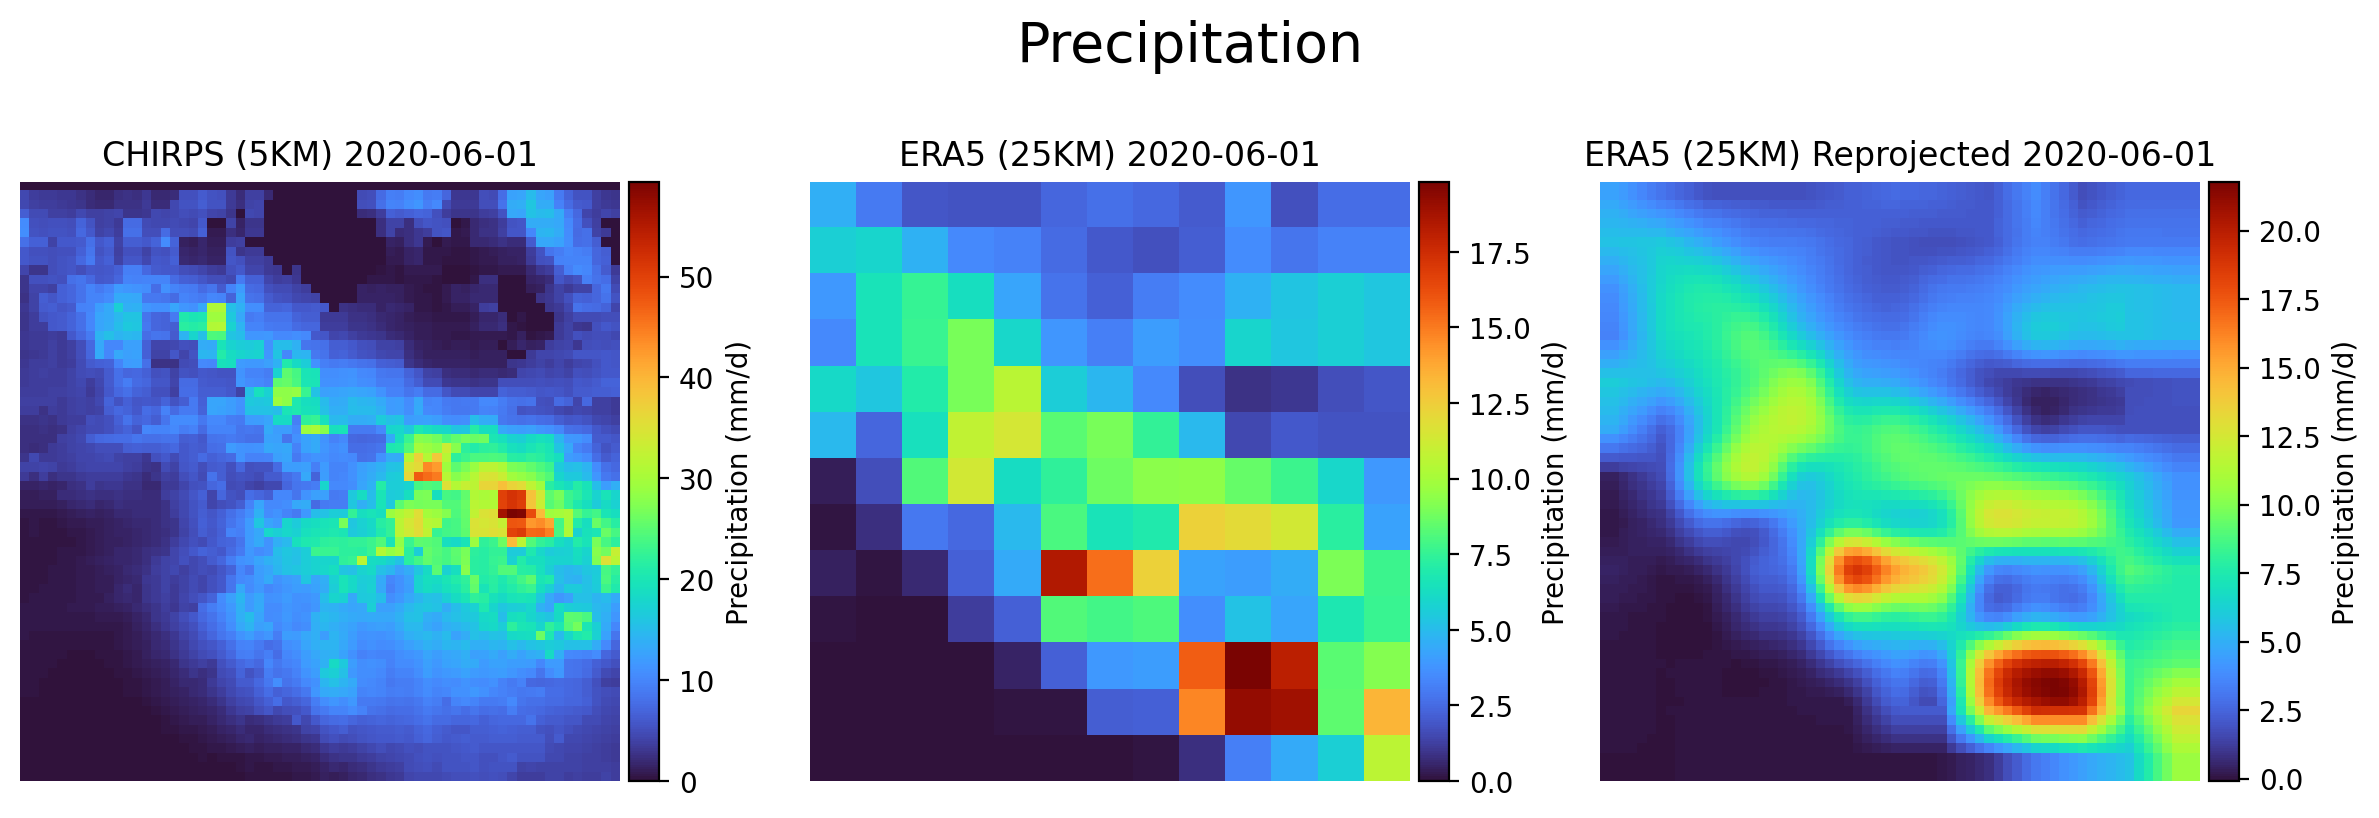

In [15]:
i = 14_396
chirps_image = np.copy(chirps_dataset[i]) # Get precipitation band
original_era5_image = np.copy(original_era5_dataset[i, 2])
reprojected_era5_image = np.copy(reprojected_era5_dataset[i, 2])

fig, ax = plt.subplots(1, 3, figsize=(12,7), dpi=200)

image_0 = ax[0].imshow(chirps_image, cmap="turbo")
ax[0].set_title(f"CHIRPS (5KM) {chirps_dates[i]}")
ax[0].set_axis_off()
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_0, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

image_1 = ax[1].imshow(original_era5_image, cmap="turbo")
ax[1].set_title(f"ERA5 (25KM) {era5_dates[i]}")
ax[1].set_axis_off()
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

image_2 = ax[2].imshow(reprojected_era5_image, cmap="turbo")
ax[2].set_title(f"ERA5 (25KM) Reprojected {era5_dates[i]}")
ax[2].set_axis_off()
divider = make_axes_locatable(ax[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(image_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)");

# plt.suptitle(f"{chirps_dates[i]}")
plt.suptitle("Precipitation",x=0.5, y=0.8, fontsize=20)
plt.tight_layout()
# chirps_image.shape, original_era5_image.shape

## Mean Daily Precipitation

In [16]:
chirps_dataset.shape

(16314, 64, 64)

In [17]:
# fig, axs = plt.subplots(1, 2, figsize=(16, 7))
chirps_mean_daily_precipitation = chirps_dataset.mean(axis=(1,2))
era5_mean_daily_precipitation = original_era5_dataset.mean(axis=(1,2))

plot = px.line(
    x=chirps_dates,
    y=chirps_mean_daily_precipitation,
    title="Mean Daily Precipitaion | CHIRPS",
    labels=["og", "kl"]
)
plot.update_layout(
    xaxis_title="Time",
    yaxis_title="Mean Precipitation (mm/d)"
)
plot.show()
# axs[0].plot(chirps_dates, chirps_mean_daily_precipitation)
# axs[0].set_title("CHIRPS")
# axs[0].tick_params("x", rotation=45)
# # axs[0].set_xticks(chirps_dates, rotation=45)

# axs[1].plot(era5_dates, era5_mean_daily_precipitation)
# axs[1].set_title("ERA5")
# axs[1].tick_params("x", rotation=45)

# plt.suptitle("Mean Daily Precipitation")
# plt.tight_layout()

### SDII

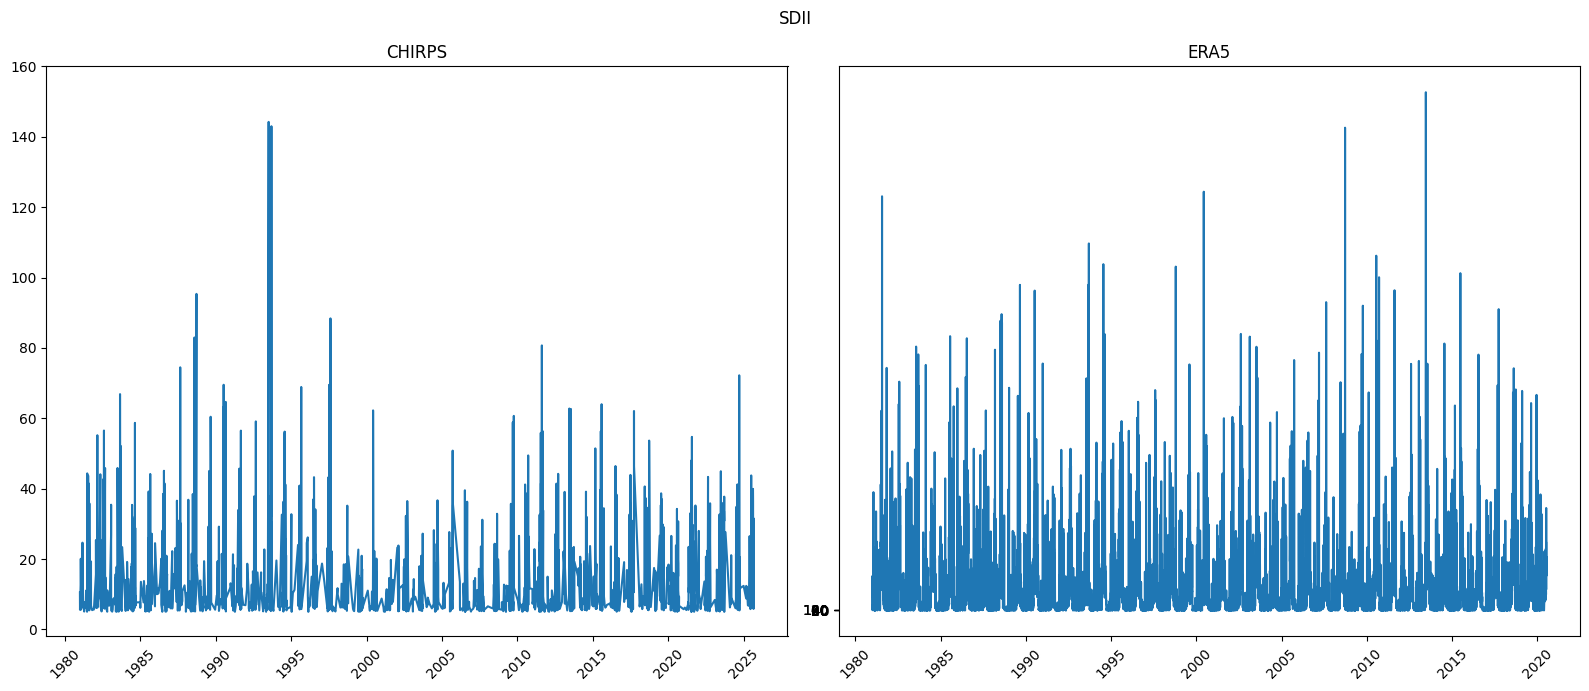

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
chirps_mean_daily_precipitation = chirps_dataset.mean(axis=(1,2))
era5_mean_daily_precipitation = original_era5_dataset[:,2].mean(axis=(1,2))*1000


# For SDII get precipitation > 1mm
chirps_mask = chirps_mean_daily_precipitation > 5
era5_mask = era5_mean_daily_precipitation > 5

filtered_chirps = chirps_mean_daily_precipitation[chirps_mask]
filtered_era5 = era5_mean_daily_precipitation[era5_mask]

filtered_chirps_dates = chirps_dates[chirps_mask]
filtered_era5_dates = era5_dates[era5_mask]

axs[0].plot(filtered_chirps_dates, filtered_chirps)
axs[0].set_title("CHIRPS")
axs[0].set_yticks(range(0, 180, 20))
axs[0].tick_params("x", rotation=45)
# axs[0].set_xticks(chirps_dates, rotation=45)

axs[1].plot(filtered_era5_dates, filtered_era5)
axs[1].set_title("ERA5")
axs[1].set_yticks(range(0, 180, 20))
axs[1].tick_params("x", rotation=45)

plt.suptitle("SDII")
plt.tight_layout()

## Zoomed in Mean Daily Precipitation

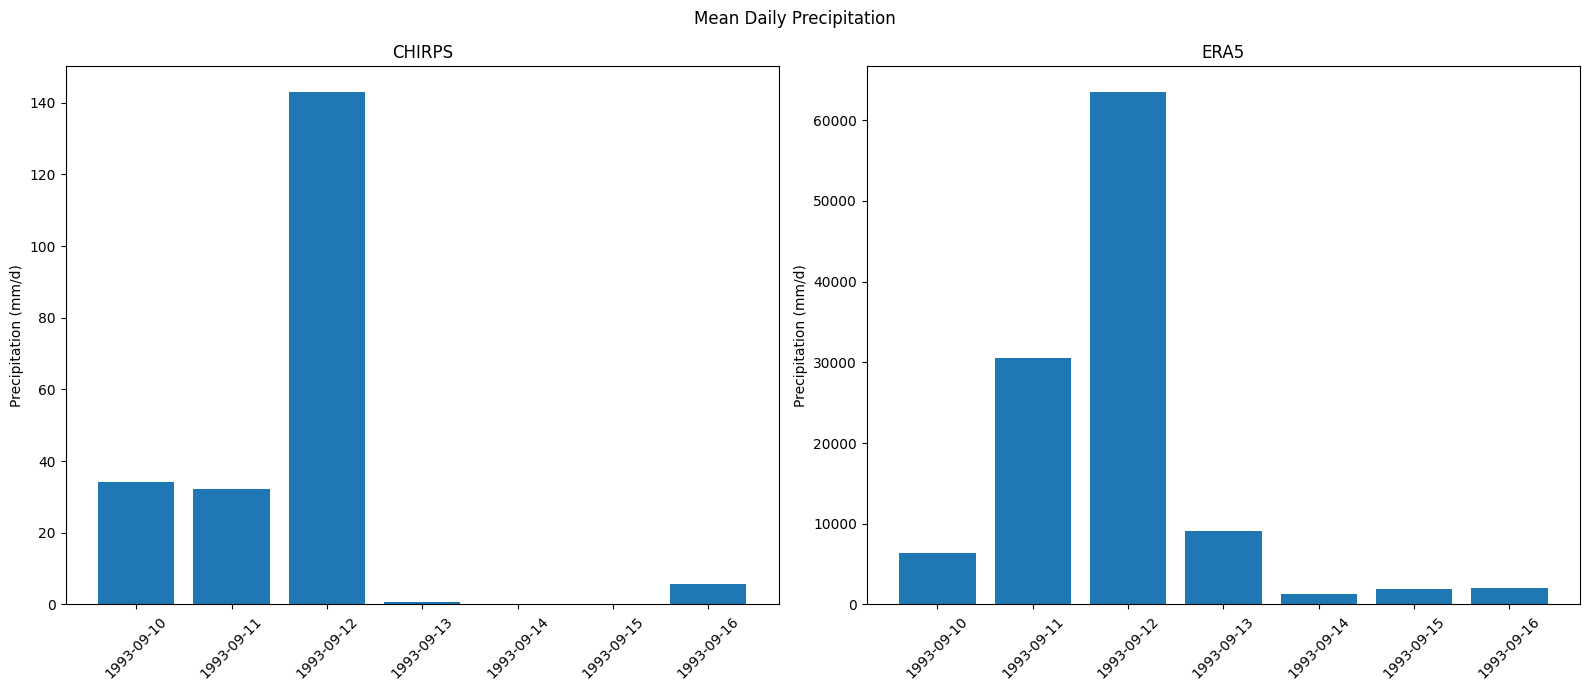

In [19]:
i_start = int(365*12.7)
i_end = int(365*12.72)
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
chirps_mean_daily_precipitation = chirps_dataset.mean(axis=(1,2))
era5_mean_daily_precipitation = original_era5_dataset[:,2].mean(axis=(1,2))*1000
axs[0].bar(chirps_dates[i_start:i_end], chirps_mean_daily_precipitation[i_start:i_end])
axs[0].set_title("CHIRPS")
axs[0].tick_params("x", rotation=45)
axs[0].set_ylabel("Precipitation (mm/d)")
# axs[0].set_xticks(chirps_dates[i_start:i_end], rotation=45)

axs[1].bar(era5_dates[i_start:i_end], era5_mean_daily_precipitation[i_start:i_end])
axs[1].set_title("ERA5")
axs[1].tick_params("x", rotation=45)
axs[1].set_ylabel("Precipitation (mm/d)")

plt.suptitle("Mean Daily Precipitation")
plt.tight_layout()

## Precipitation Distribution

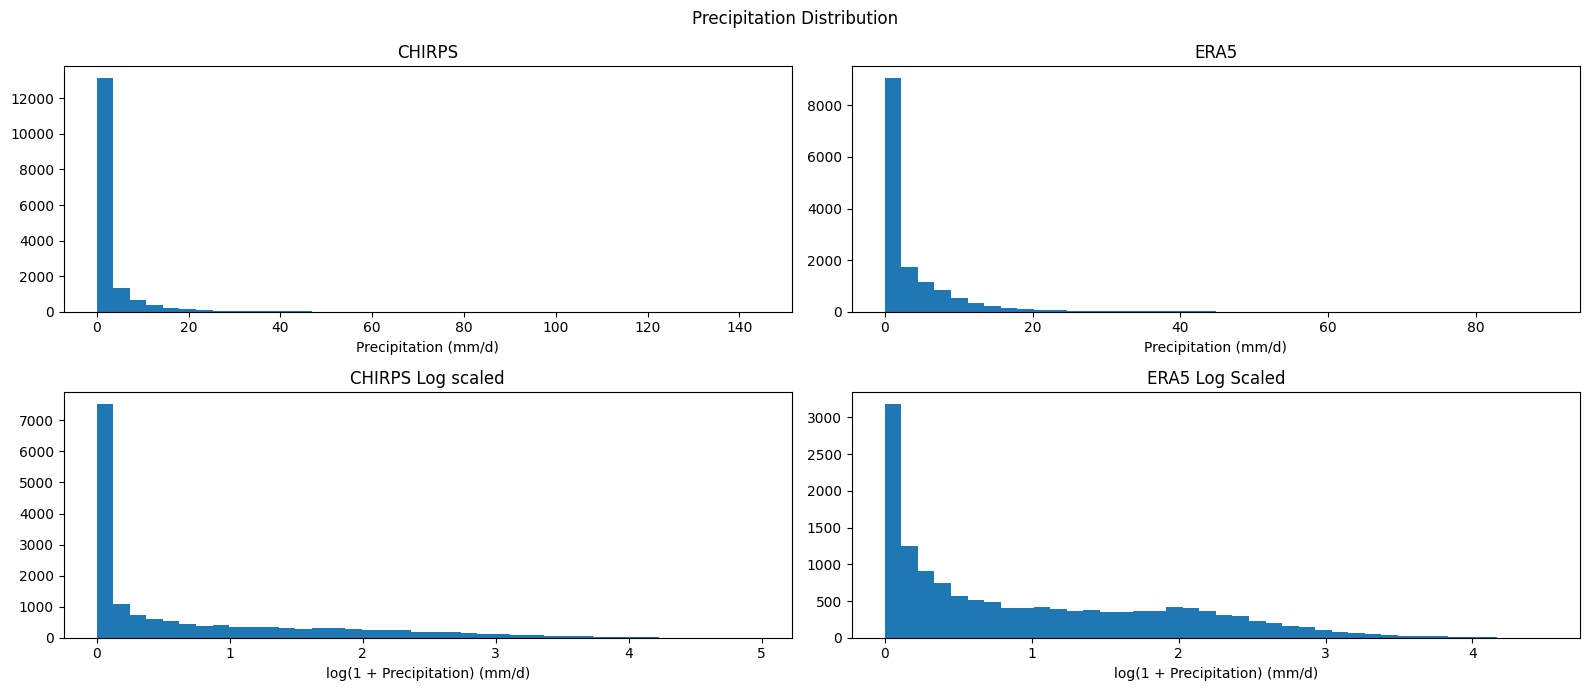

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(16, 7))
chirps_mean_daily_precipitation = chirps_dataset.mean(axis=(1,2))
era5_mean_daily_precipitation = original_era5_dataset[:,2].mean(axis=(1,2))

axs[0, 0].hist(chirps_mean_daily_precipitation, bins=40)
axs[0, 0].set_title("CHIRPS")
axs[0, 0].set_xlabel("Precipitation (mm/d)")

axs[0, 1].hist(era5_mean_daily_precipitation, bins=40)
axs[0, 1].set_title("ERA5")
axs[0, 1].set_xlabel("Precipitation (mm/d)")

axs[1, 0].hist(np.log(1 + chirps_mean_daily_precipitation), bins=40)
axs[1, 0].set_title("CHIRPS Log scaled")
axs[1, 0].set_xlabel("log(1 + Precipitation) (mm/d)")

axs[1, 1].hist(np.log(1 + era5_mean_daily_precipitation), bins=40)
axs[1, 1].set_title("ERA5 Log Scaled")
axs[1, 1].set_xlabel("log(1 + Precipitation) (mm/d)")

plt.suptitle("Precipitation Distribution")
plt.tight_layout()

## Bias plot

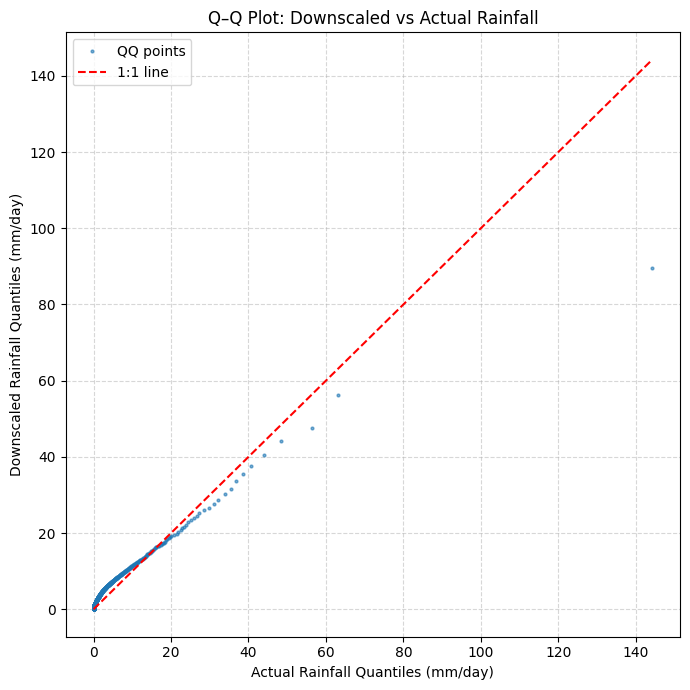

Mean Bias: 0.836
RMSE: 5.639


In [61]:
N = len(era5_mean_daily_precipitation)
plot_bias_using_QQ_plot(era5_mean_daily_precipitation, chirps_mean_daily_precipitation[:N])

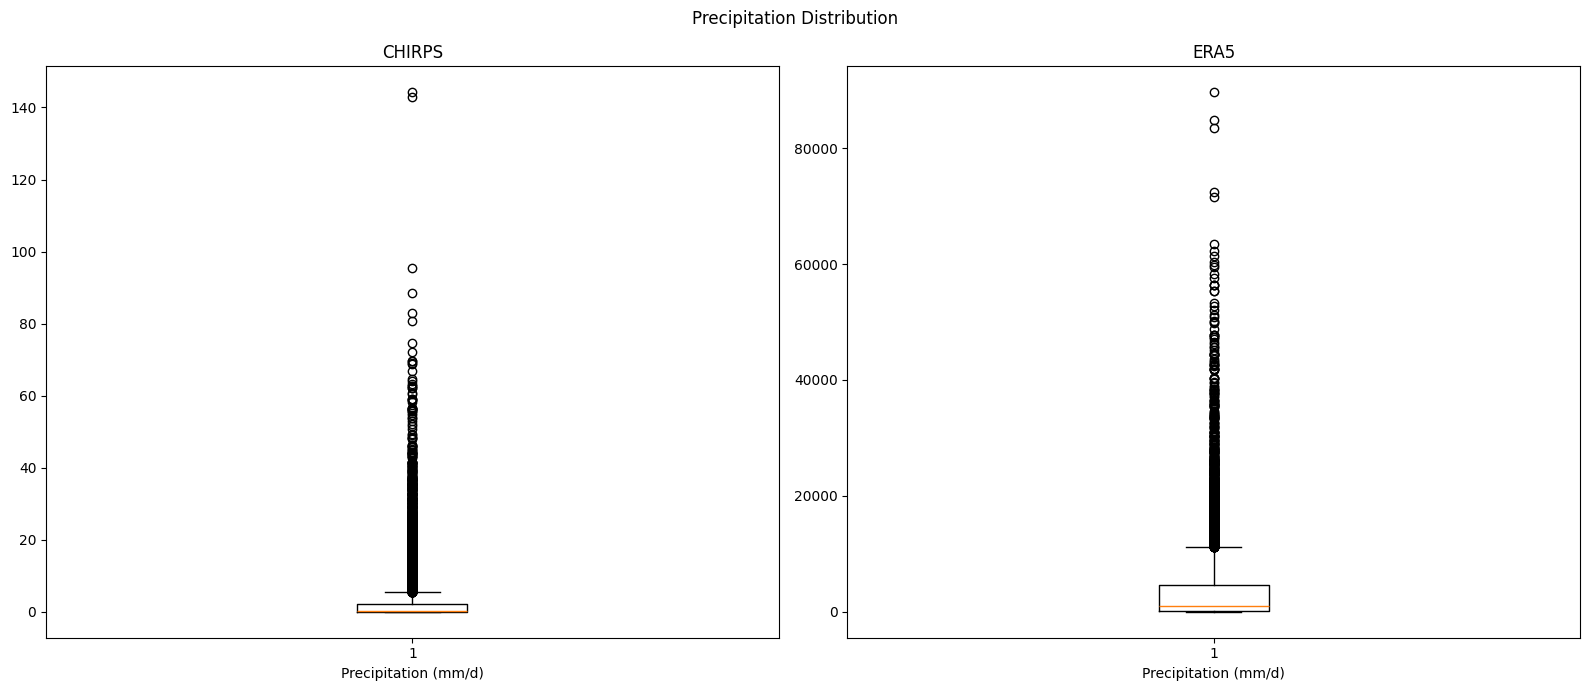

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7))
chirps_mean_daily_precipitation = chirps_dataset.mean(axis=(1,2))
era5_mean_daily_precipitation = original_era5_dataset[:,2].mean(axis=(1,2))*1000

chirps_boxplot = axs[0].boxplot(chirps_mean_daily_precipitation)
axs[0].set_title("CHIRPS")
axs[0].set_xlabel("Precipitation (mm/d)")

era5_boxplot = axs[1].boxplot(era5_mean_daily_precipitation)
axs[1].set_title("ERA5")
axs[1].set_xlabel("Precipitation (mm/d)")

plt.suptitle("Precipitation Distribution")
plt.tight_layout()

In [22]:
np.median(chirps_mean_daily_precipitation), np.median(era5_mean_daily_precipitation)

(np.float32(0.20632522), np.float32(981.62195))

## Mean Precipitation
Mean precipitation is calculated by just doing `sum` of rainfall and not actual `mean`.

In [23]:
def calculate_means(dates, grids):
    """Using pandas for more sophisticated time grouping"""
    
    # Convert to a format pandas can work with
    # dates = list(data.keys())
    # grids = list(data.values())
    
    # Create a DataFrame with dates
    df = pd.DataFrame({'date': dates, 'grid': grids.flatten()})
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Monthly means
    monthly_means = {}
    for period, group in df.groupby(pd.Grouper(freq='ME')):
        if len(group) > 0:
            monthly_means[period] = np.mean(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Yearly means
    yearly_means = {}
    for period, group in df.groupby(pd.Grouper(freq='YE')):
        if len(group) > 0:
            yearly_means[period] = np.mean(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Decadal means (10 years)
    decadal_means = {}
    for period, group in df.groupby(pd.Grouper(freq='10YE')):
        if len(group) > 0:
            decadal_means[period] = np.mean(np.stack(group['grid'].values), axis=0) # type: ignore
    
    return monthly_means, yearly_means, decadal_means

In [24]:
monthly_means, yearly_means, decadal_means = calculate_means(chirps_dates, chirps_dataset.reshape(-1, 4096).mean(axis=1))

### Monthly Mean Precipitation

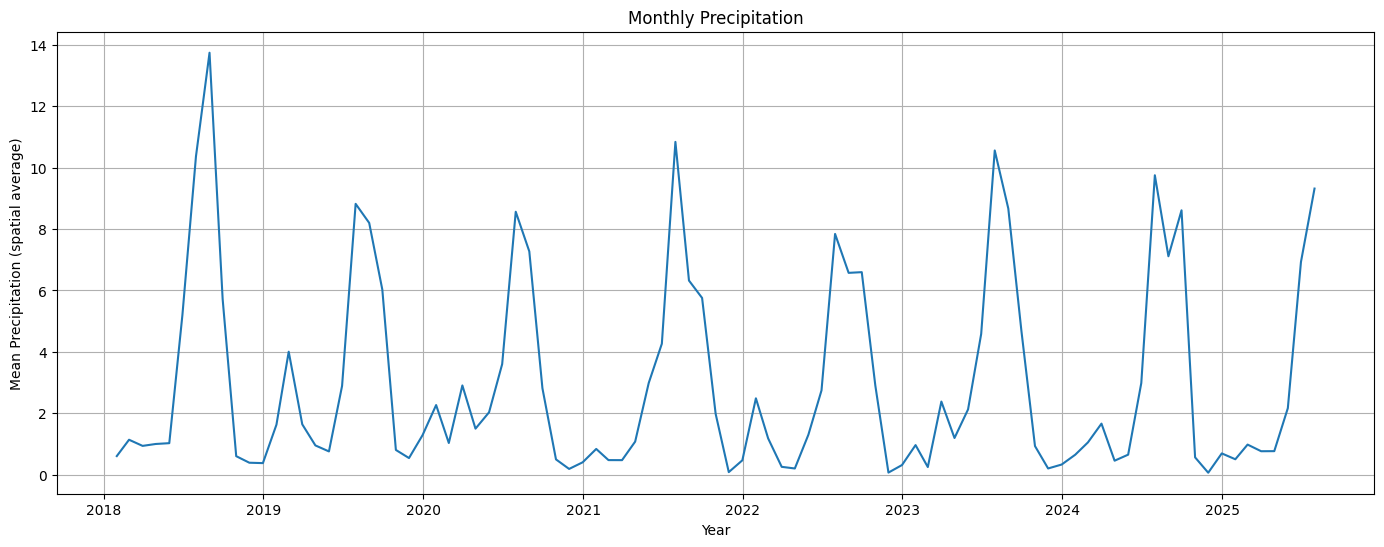

In [25]:
FIRST_N_MONTHS = -92
LAST_N_MONTHS = -1
months = sorted(monthly_means.keys())[FIRST_N_MONTHS:LAST_N_MONTHS]
spatial_means = [monthly_means[year] for year in months]

plt.figure(figsize=(17, 6))
plt.plot(months, spatial_means)
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Monthly Precipitation')
plt.grid(True)

### 1. FIT A TIME SERIES MODEL

### Extracting Trend and Seasonality

We do not have enough data available for `2025`, so removing it from seasonality and trend calulation

In [26]:
months = sorted(monthly_means.keys())[:-8]
spatial_means = [monthly_means[year] for year in months]
rainfall_cycle, rainfall_trend = sm.tsa.filters.hpfilter(spatial_means)

/workspace/.venv/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning:

spsolve requires A be CSC or CSR matrix format



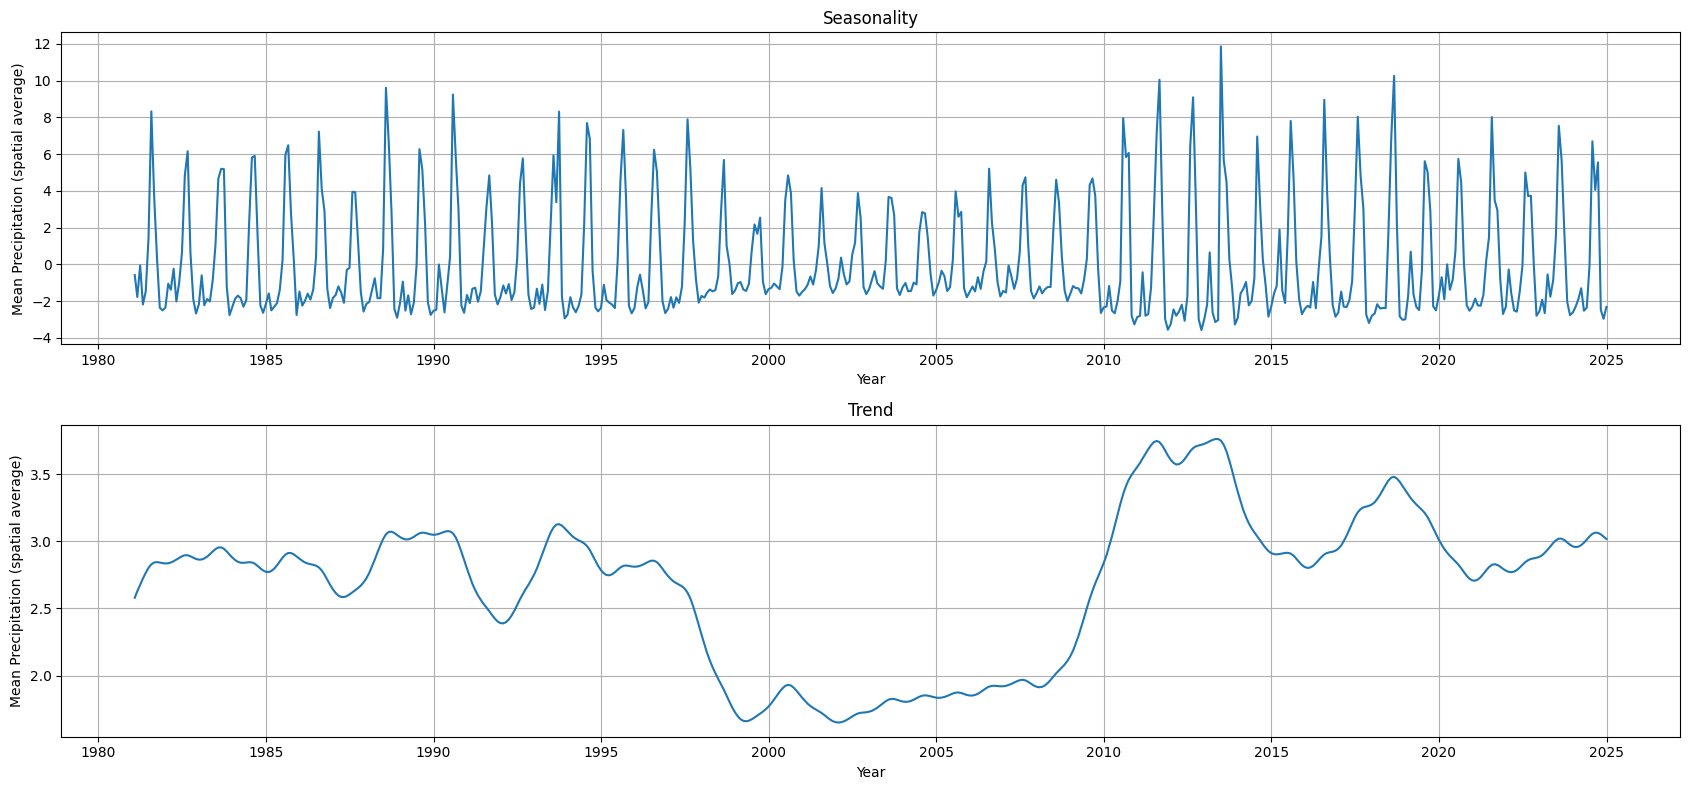

In [27]:
plt.figure(figsize=(17, 8))
plt.subplot(2, 1, 1)
plt.plot(months, rainfall_cycle)
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Seasonality')
plt.grid(True)

plt.subplot(2, 1, 2)
# plt.plot(months, spatial_means)
plt.plot(months, rainfall_trend, label="Trend")
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Trend')
plt.grid(True)

plt.tight_layout()

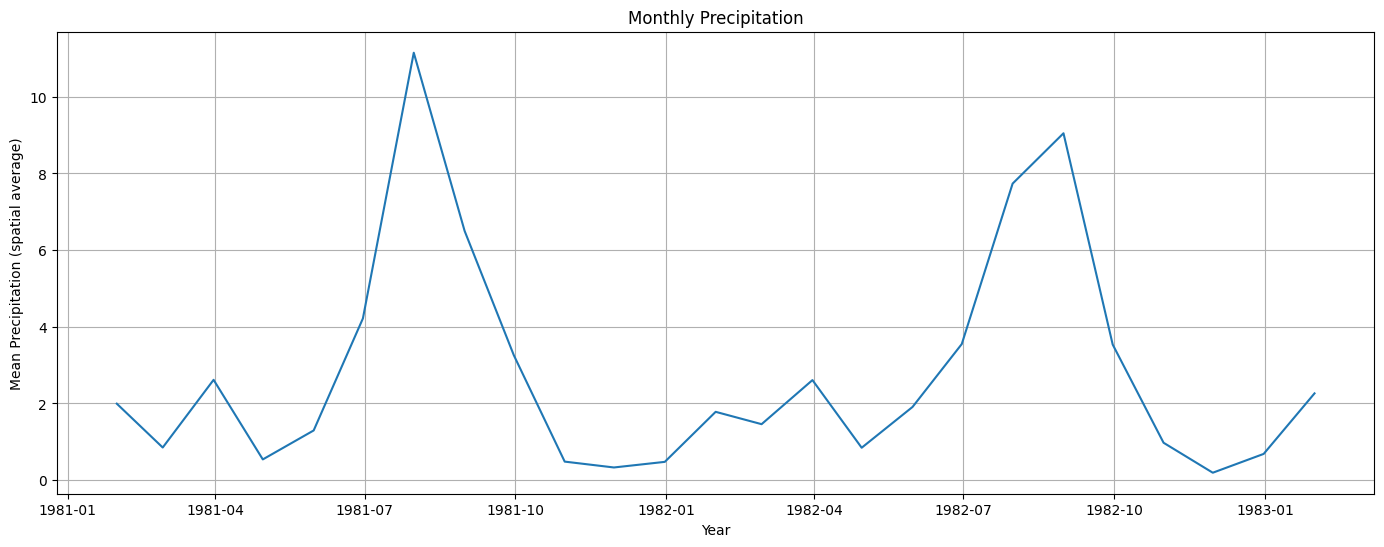

In [28]:
FIRST_N_MONTHS = 0
LAST_N_MONTHS = 25
months = sorted(monthly_means.keys())[FIRST_N_MONTHS:LAST_N_MONTHS]
spatial_means = [monthly_means[year] for year in months]

plt.figure(figsize=(17, 6))
plt.plot(months, spatial_means)
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Monthly Precipitation')
plt.grid(True)

#### Based on these plots in `Uttarakhand`, monsoon season starts from month of `July` to `October`. Only these months contribute to majority of rainfall thus, we are dropping all other months from our dataset.

### Yearly Mean Precipitation

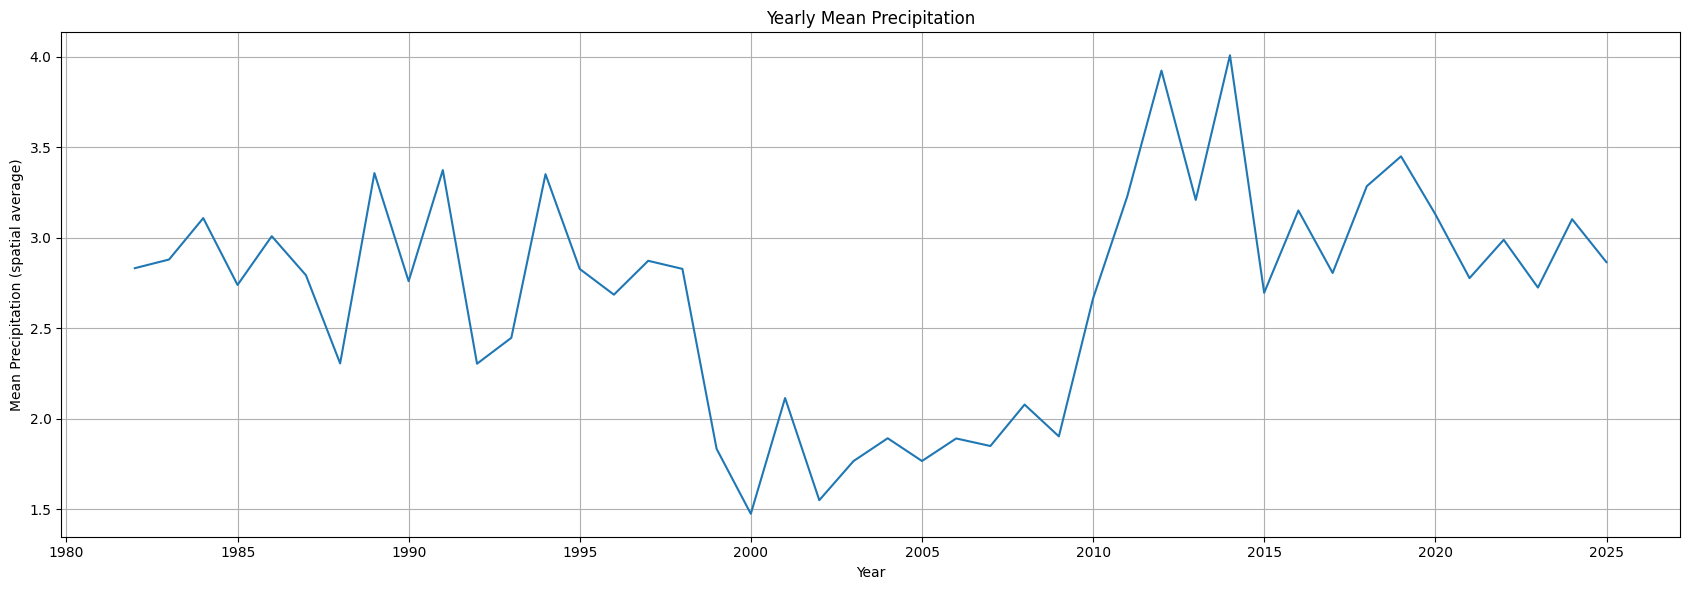

In [29]:
years = sorted(yearly_means.keys())[:-1]
spatial_means = [yearly_means[year] for year in years]

plt.figure(figsize=(17, 6))
plt.plot(years, spatial_means)
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Yearly Mean Precipitation')
plt.grid(True)
plt.tight_layout()

### Decadal Mean Precipitation

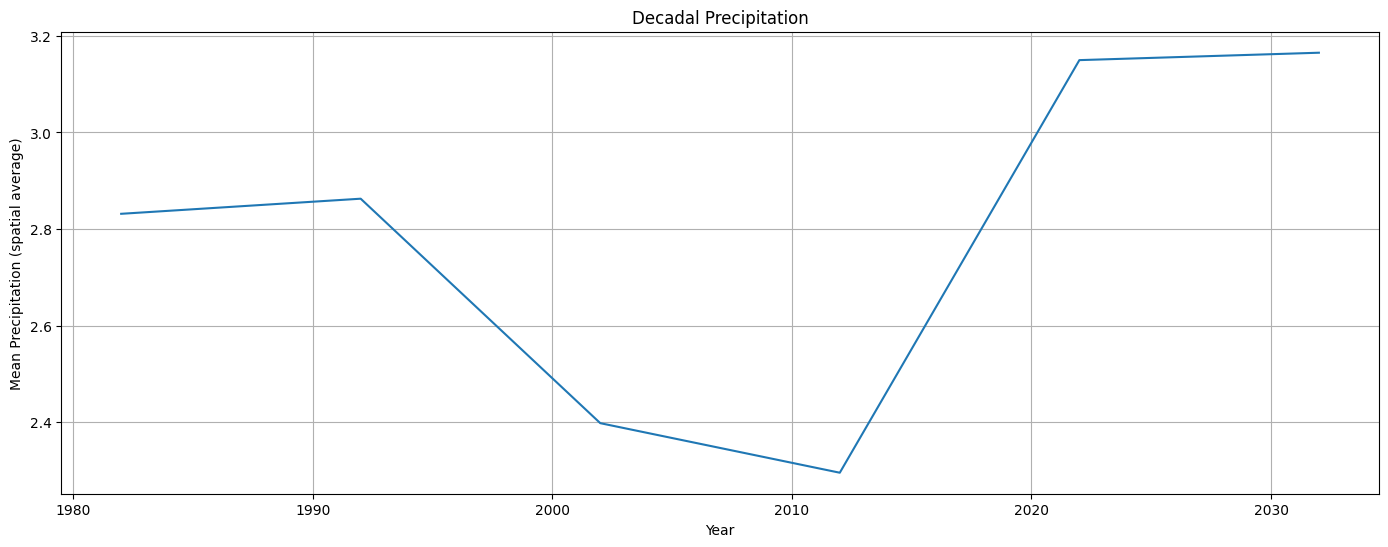

In [30]:
decades = sorted(decadal_means.keys())
spatial_means = [decadal_means[year] for year in decades]

plt.figure(figsize=(17, 6))
plt.plot(decades, spatial_means)
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Decadal Precipitation')
plt.grid(True)

## Median Precipitation

In [31]:
def calculate_medians(dates, grids):
    """Using pandas for more sophisticated time grouping"""
    
    # Convert to a format pandas can work with
    # dates = list(data.keys())
    # grids = list(data.values())
    
    # Create a DataFrame with dates
    df = pd.DataFrame({'date': dates, 'grid': grids.flatten()})
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Monthly medians
    monthly_medians = {}
    for period, group in df.groupby(pd.Grouper(freq='ME')):
        if len(group) > 0:
            monthly_medians[period] = np.median(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Yearly medians
    yearly_medians = {}
    for period, group in df.groupby(pd.Grouper(freq='YE')):
        if len(group) > 0:
            yearly_medians[period] = np.median(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Decadal medians (10 years)
    decadal_medians = {}
    for period, group in df.groupby(pd.Grouper(freq='10YE')):
        if len(group) > 0:
            decadal_medians[period] = np.median(np.stack(group['grid'].values), axis=0) # type: ignore
    
    return monthly_medians, yearly_medians, decadal_medians

In [32]:
monthly_medians, yearly_medians, decadal_medians = calculate_medians(chirps_dates, chirps_dataset.reshape(-1, 4096).mean(axis=1))

### Daily Median Precipitaion

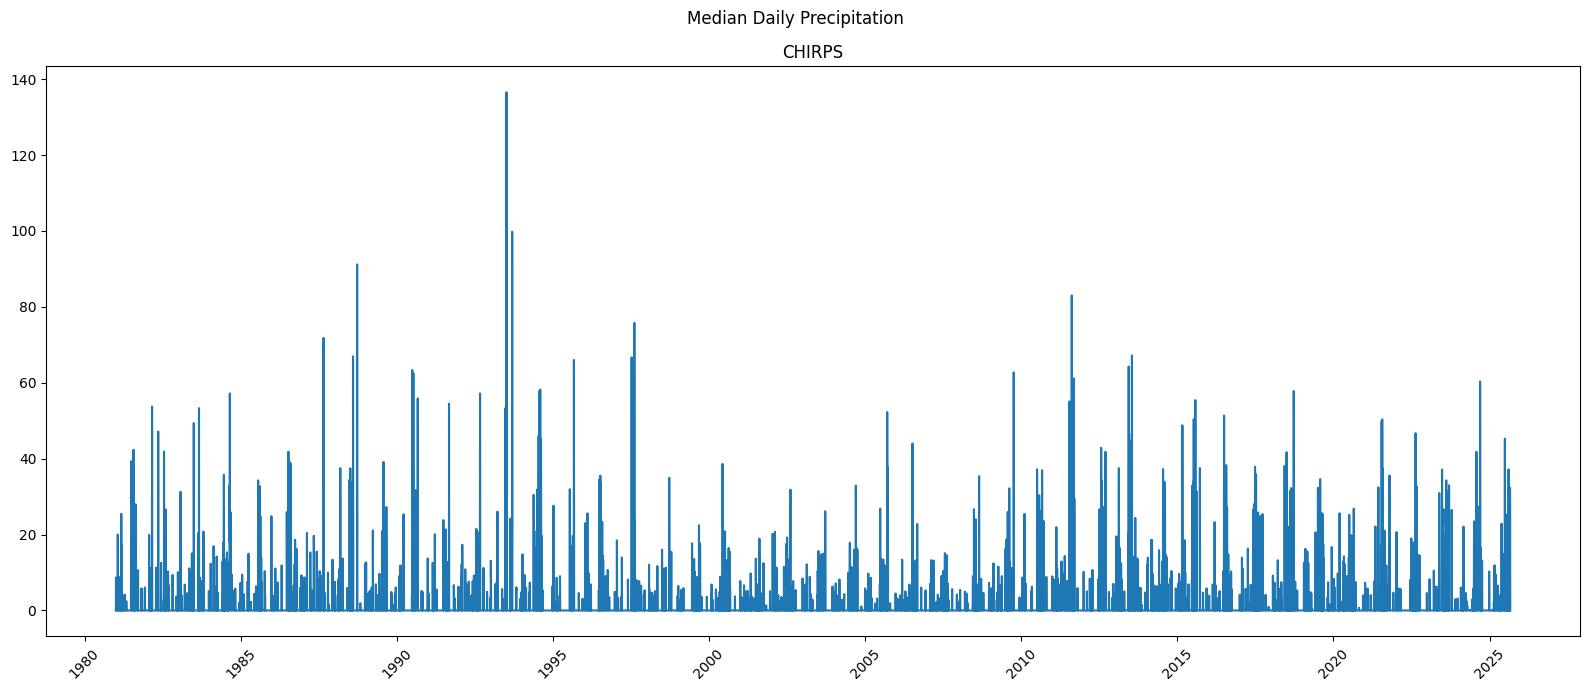

In [33]:
# fig, axs = plt.subplots(1, 2, figsize=(16, 7))
fig, axs = plt.subplots(1, 1, figsize=(16, 7))
chirps_median_daily_precipitation = np.median(chirps_dataset, axis=(1,2))
# era5_median_daily_precipitation = np.median(original_era5_dataset, axis=(1,2))*1000

axs.plot(chirps_dates, chirps_median_daily_precipitation)
axs.set_title("CHIRPS")
axs.tick_params("x", rotation=45)

# axs[0].plot(chirps_dates, chirps_median_daily_precipitation)
# axs[0].set_title("CHIRPS")
# axs[0].tick_params("x", rotation=45)
# axs[0].set_xticks(chirps_dates, rotation=45)

# axs[1].plot(era5_dates, era5_median_daily_precipitation)
# axs[1].set_title("ERA5")
# axs[1].tick_params("x", rotation=45)

plt.suptitle("Median Daily Precipitation")
plt.tight_layout()

### Monthly Median Precipitation

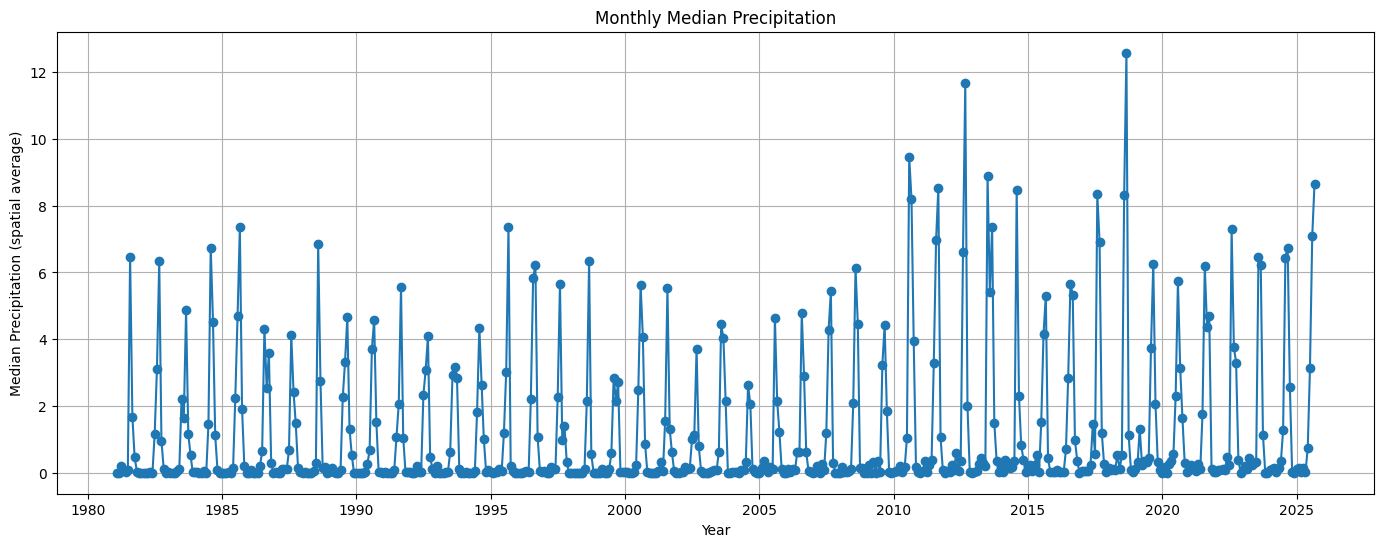

In [34]:
months = sorted(monthly_medians.keys())
spatial_medians = [(monthly_medians[year]) for year in months]

plt.figure(figsize=(17, 6))
plt.plot(months, spatial_medians, marker='o')
plt.xlabel('Year')
plt.ylabel('Median Precipitation (spatial average)')
plt.title('Monthly Median Precipitation')
plt.grid(True)

### Yearly Median Precipitaion

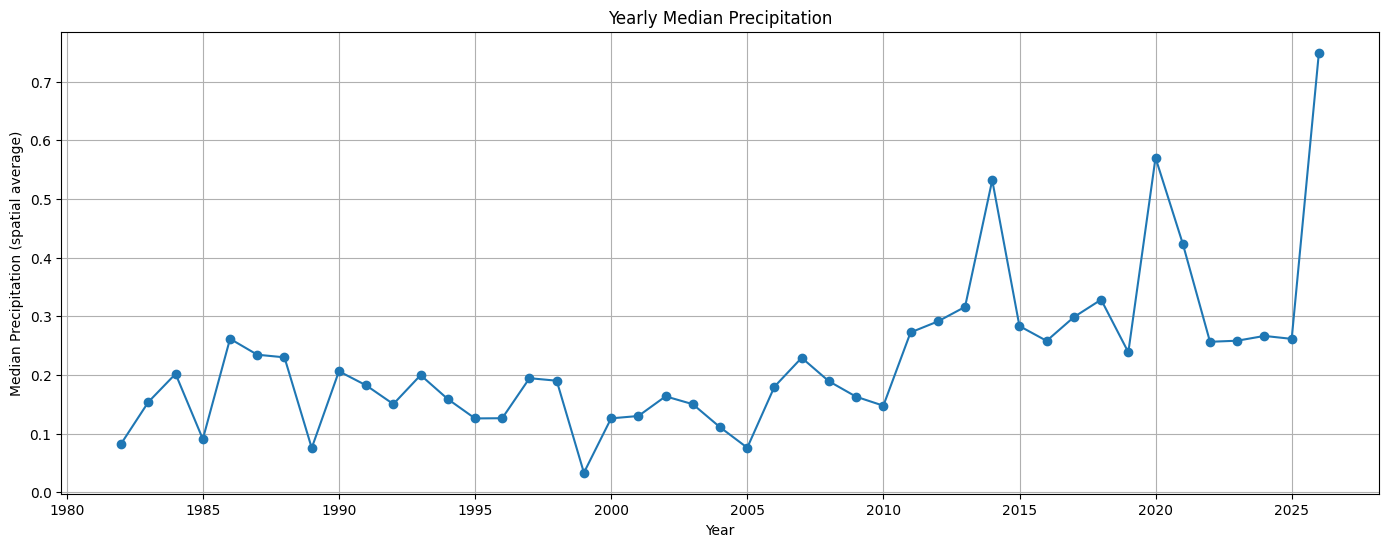

In [35]:
years = sorted(yearly_medians.keys())
spatial_medians = [(yearly_medians[year]) for year in years]

plt.figure(figsize=(17, 6))
plt.plot(years, spatial_medians, marker='o')
plt.xlabel('Year')
plt.ylabel('Median Precipitation (spatial average)')
plt.title('Yearly Median Precipitation')
plt.grid(True)

## Extreme Events

In [36]:
def calculate_extremes(dates, grids):
    """Using pandas for more sophisticated time grouping"""
    
    # Convert to a format pandas can work with
    # dates = list(data.keys())
    # grids = list(data.values())
    
    # Create a DataFrame with dates
    df = pd.DataFrame({'date': dates, 'grid': grids.flatten()})
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    
    # Monthly extremes
    monthly_extremes = {}
    for period, group in df.groupby(pd.Grouper(freq='ME')):
        if len(group) > 0:
            monthly_extremes[period] = np.max(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Yearly extremes
    yearly_extremes = {}
    for period, group in df.groupby(pd.Grouper(freq='YE')):
        if len(group) > 0:
            yearly_extremes[period] = np.max(np.stack(group['grid'].values), axis=0) # type: ignore
    
    # Decadal extremes (10 years)
    decadal_extremes = {}
    for period, group in df.groupby(pd.Grouper(freq='10YE')):
        if len(group) > 0:
            decadal_extremes[period] = np.max(np.stack(group['grid'].values), axis=0) # type: ignore
    
    return monthly_extremes, yearly_extremes, decadal_extremes

In [37]:
monthly_extremes, yearly_extremes, decadal_extremes = calculate_extremes(chirps_dates, chirps_dataset.reshape(-1, 4096).mean(axis=1))

### Monthly Extremes

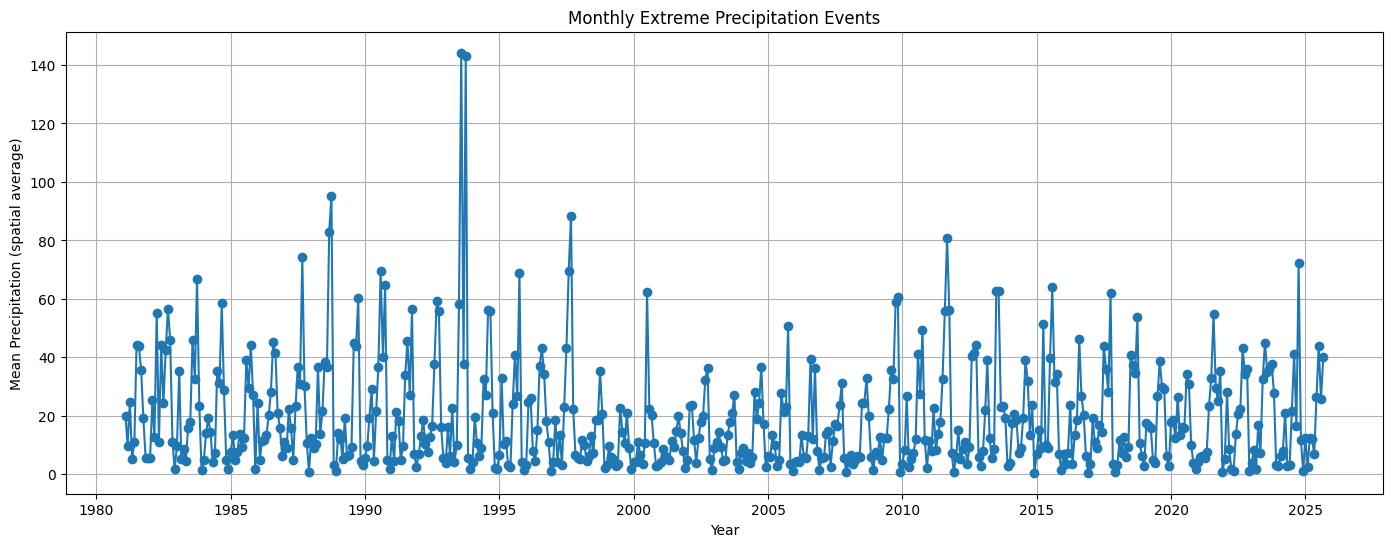

In [38]:
extreme_months = sorted(monthly_extremes.keys())
spatial_extremes = [monthly_extremes[year] for year in extreme_months]

plt.figure(figsize=(17, 6))
plt.plot(extreme_months, spatial_extremes, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Monthly Extreme Precipitation Events')
plt.grid(True)

### Yearly Extremes

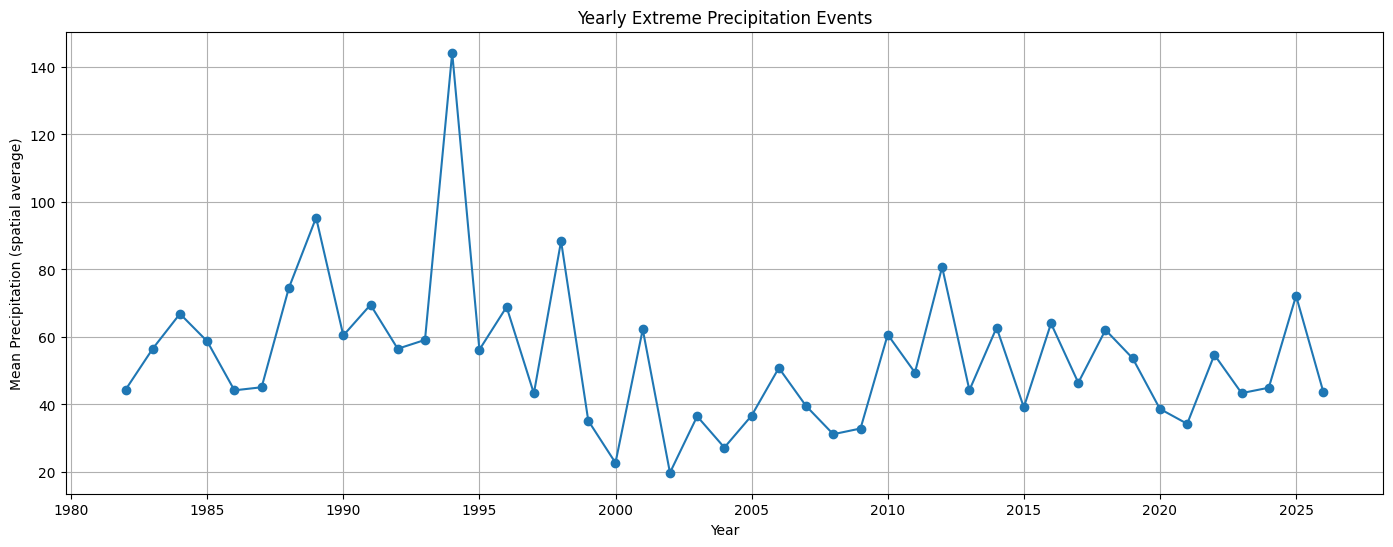

In [39]:
extreme_years = sorted(yearly_extremes.keys())
spatial_extremes = [yearly_extremes[year] for year in extreme_years]

plt.figure(figsize=(17, 6))
plt.plot(extreme_years, spatial_extremes, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Yearly Extreme Precipitation Events')
plt.grid(True)

### Decadal Extremes

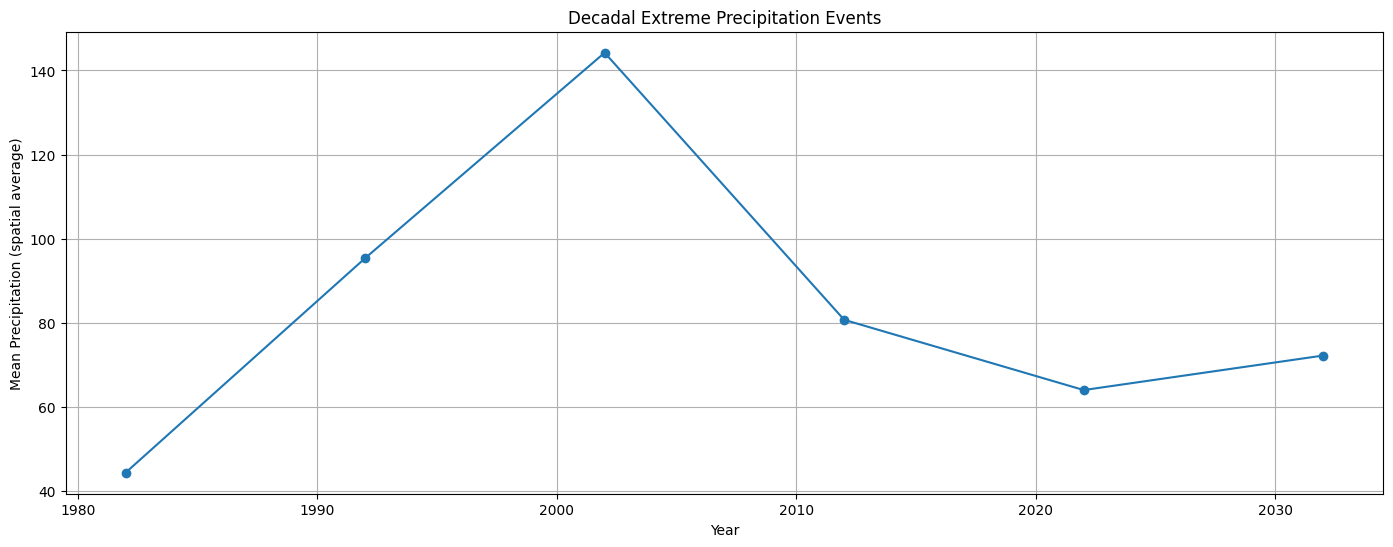

In [40]:
extreme_decades = sorted(decadal_extremes.keys())
spatial_extremes = [decadal_extremes[year] for year in extreme_decades]

plt.figure(figsize=(17, 6))
plt.plot(extreme_decades, spatial_extremes, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Precipitation (spatial average)')
plt.title('Decadal Extreme Precipitation Events')
plt.grid(True)

## Dropping months not contirbuting to rainfall
`Non-Contributing` - January, February, March, April, May, June, October, November, December \
`Contributing` - July, August, September

In [41]:
NON_CONTRIBUTING_MONTHS = [1, 2, 3, 4, 5, 6, 10, 11, 12]
CONTIRIBUTING_MONTHS = [7, 8, 9]

filtered_chirps_data_dict = {}
for date, grid in tqdm(chirps_data_dict.items(), desc="Filtering CHIPS Data", colour="BLUE"):
    if date.month in CONTIRIBUTING_MONTHS:
        filtered_chirps_data_dict[date] = grid
    
filtered_original_era5_data_dict = {}
for date, grid in tqdm(original_era5_data_dict.items(), desc="Filtering Original ERA5 Data", colour="BLUE"):
    if date.month in CONTIRIBUTING_MONTHS:
        filtered_original_era5_data_dict[date] = grid

filtered_reprojected_era5_data_dict = {}
for date, grid in tqdm(reprojected_era5_data_dict.items(), desc="Filtering Reprojected ERA5 Data", colour="BLUE"):
    if date.month in CONTIRIBUTING_MONTHS:
        filtered_reprojected_era5_data_dict[date] = grid

Filtering Reprojected ERA5 Data: 100%|██████████| 14435/14435 [00:00<00:00, 4487125.05it/s]


In [42]:
BEFORE, AFTER = len(original_era5_data_dict), len(filtered_original_era5_data_dict)
BEFORE, AFTER

(14435, 3597)

(16314, 4110)

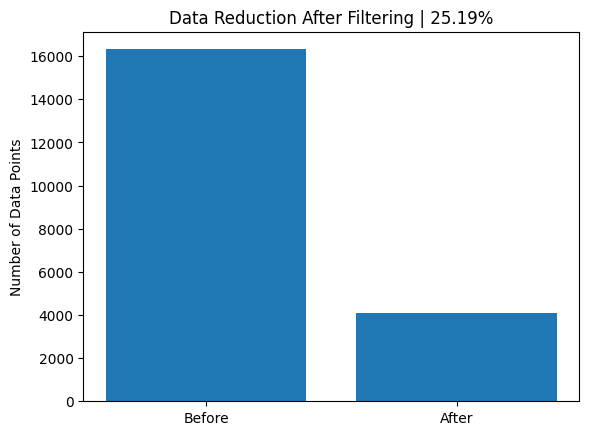

In [43]:
BEFORE, AFTER = len(chirps_data_dict), len(filtered_chirps_data_dict)
plt.bar(x=["Before", "After"], height=[BEFORE, AFTER])
plt.title(f"Data Reduction After Filtering | {(AFTER)*100/BEFORE:0.2f}%")
plt.ylabel("Number of Data Points")
BEFORE, AFTER

### Saving data

In [44]:
# try:
#     os.mkdir("./data")
# except FileExistsError:
#     print("'data' directory already exists.")

# with open('./data/chirps_data.pkl', 'wb') as file:
#     pickle.dump(filtered_chirps_data_dict, file)

# with open('./data/original_era5_data.pkl', 'wb') as file:
#     pickle.dump(filtered_original_era5_data_dict, file)

# with open('./data/reprojected_era5_data.pkl', 'wb') as file:
#     pickle.dump(filtered_reprojected_era5_data_dict, file)

In [45]:
# with open('./data/chirps_data.pkl', 'rb') as file:
#     filtered_chirps_data_dict = pickle.load(file)

# with open('./data/original_era5_data.pkl', 'rb') as file:
#     filtered_original_era5_data_dict = pickle.load(file)

# with open('./data/reprojected_era5_data.pkl', 'rb') as file:
#     filtered_reprojected_era5_data_dict = pickle.load(file)

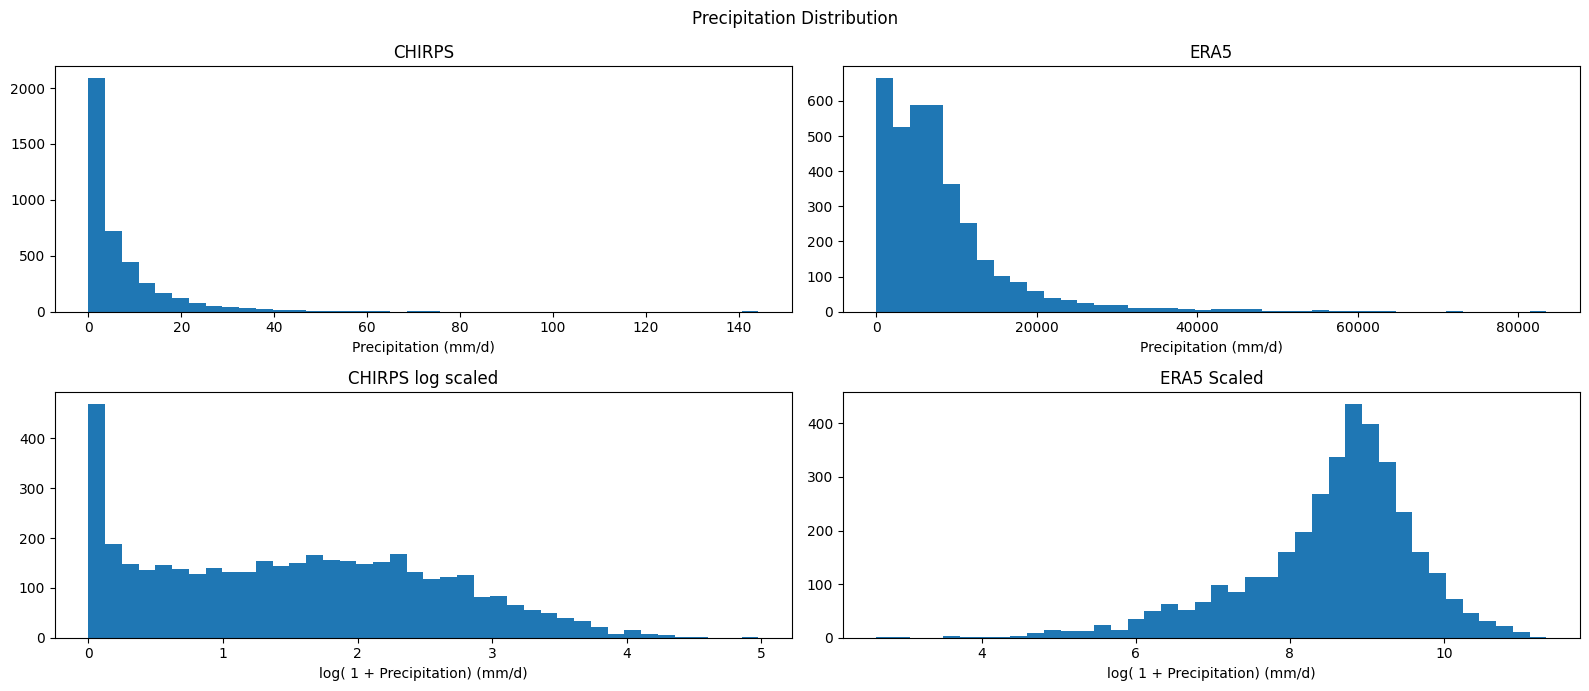

In [46]:
fig, axs = plt.subplots(2, 2, figsize=(16, 7))
filtered_chirps = np.array(list(filtered_chirps_data_dict.values()))
filtered_era5 = np.array(list(filtered_original_era5_data_dict.values()))

chirps_mean_daily_precipitation = filtered_chirps.mean(axis=(1,2))
era5_mean_daily_precipitation = filtered_era5[:,2].mean(axis=(1,2))*1000

axs[0, 0].hist(chirps_mean_daily_precipitation, bins=40)
axs[0, 0].set_title("CHIRPS")
axs[0, 0].set_xlabel("Precipitation (mm/d)")

axs[0, 1].hist(era5_mean_daily_precipitation, bins=40)
axs[0, 1].set_title("ERA5")
axs[0, 1].set_xlabel("Precipitation (mm/d)")

axs[1, 0].hist(np.log(1 + chirps_mean_daily_precipitation), bins=40)
axs[1, 0].set_title("CHIRPS log scaled")
axs[1, 0].set_xlabel("log( 1 + Precipitation) (mm/d)")

axs[1, 1].hist(np.log(1 + era5_mean_daily_precipitation), bins=40)
axs[1, 1].set_title("ERA5 Scaled")
axs[1, 1].set_xlabel("log( 1 + Precipitation) (mm/d)")

plt.suptitle("Precipitation Distribution")
plt.tight_layout()

## Extracting trend

In [47]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cv2

Original Extreme = 134.74365234375 | Blurred Extreme = 134.74365234375


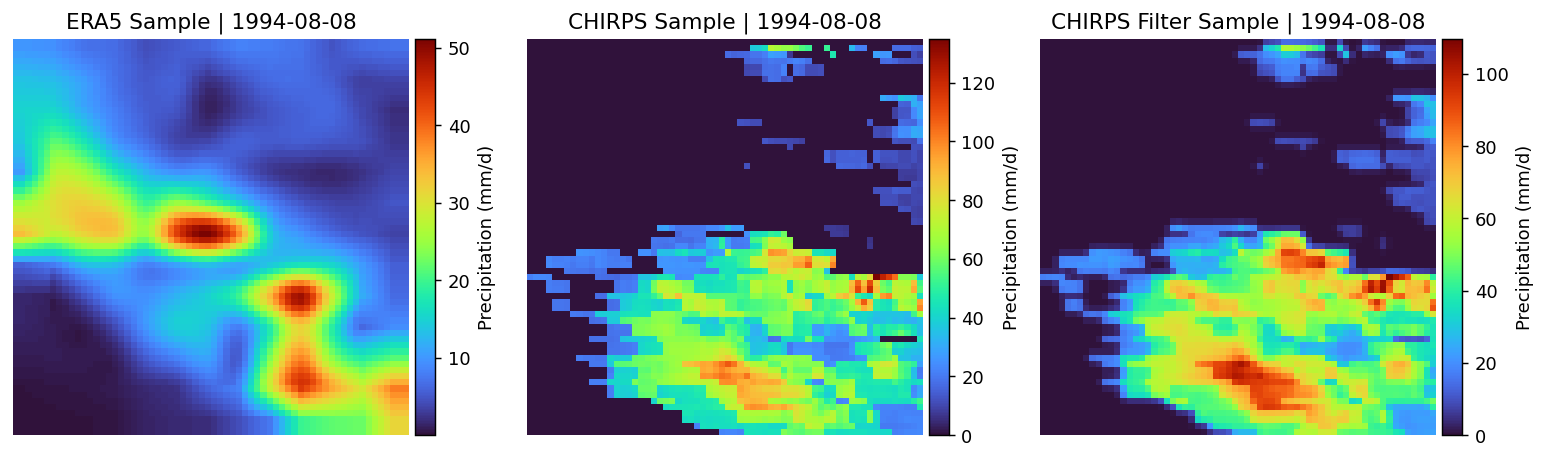

In [48]:
# era5_count = 0
# chirps_count = 0
# for img in reprojected_era5_dataset:
#     if (img > 2).sum() > 32:
#         era5_sample = img
#         era5_count += 1
#         break
count = 0
n = len(reprojected_era5_dataset)
for chirps_date, era5_date, chirps, era5 in zip(chirps_dates[:n], era5_dates, chirps_dataset[:n], reprojected_era5_dataset):
    if (chirps > 2).sum() > 256:
        chirps_sample = chirps
        era5_sample = era5
        era5_date_sample = era5_date
        chirps_date_sample = chirps_date
        count += 1
    if count > 2000:
        break
        # break
# print(era5_count, chirps_count)
# print(era5_date_sample, chirps_date_sample)

k = 3
sigma = 0.5
d_ = 1

gaussian_chirps_sample = cv2.GaussianBlur(chirps_sample, ksize=(k, k), sigmaX=sigma, sigmaY=sigma)
sobel_chirps_sample = cv2.Sobel(chirps_sample, ddepth=cv2.CV_32F, dx=d_, dy=d_, ksize=k)

fig, axs = plt.subplots(1, 3, figsize=(12, 7),dpi=130)
fig_1 = axs[0].imshow(era5_sample[2], cmap="turbo")
axs[0].set_title(f"ERA5 Sample | {era5_date_sample}")
axs[0].set_axis_off()
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(fig_1, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

fig_2 = axs[1].imshow(chirps_sample, cmap="turbo")
axs[1].set_title(f"CHIRPS Sample | {chirps_date_sample}")
axs[1].set_axis_off()
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(fig_2, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

fig_3 = axs[2].imshow(np.abs(gaussian_chirps_sample), cmap="turbo")
axs[2].set_title(f"CHIRPS Filter Sample | {chirps_date_sample}")
axs[2].set_axis_off()
divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(fig_3, cax=cax, orientation="vertical", label="Precipitation (mm/d)")

plt.tight_layout()
print(f"Original Extreme = {chirps_sample.max()} | Blurred Extreme = {chirps_sample.max()}")

In [49]:
# reprojected_era5.shape

In [50]:
# len(reprojected_era5[0])

In [51]:
filtered_chirps_dates = np.array(list(filtered_chirps_data_dict.keys()))
filtered_chirps_dataset = np.array(list(filtered_chirps_data_dict.values()))
monthly_means, yearly_means, decadal_means = calculate_means(filtered_chirps_dates, filtered_chirps_dataset.reshape(-1, 4096).mean(axis=1))
months = sorted(monthly_means.keys())
spatial_means = [monthly_means[year] for year in months]

In [52]:
rainfall_cycle, rainfall_trend = sm.tsa.filters.hpfilter(spatial_means)

/workspace/.venv/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning:

spsolve requires A be CSC or CSR matrix format



In [53]:
min(spatial_means)

np.float32(1.7618519)

Text(0, 0.5, 'Mean Precipitation (mm/d)')

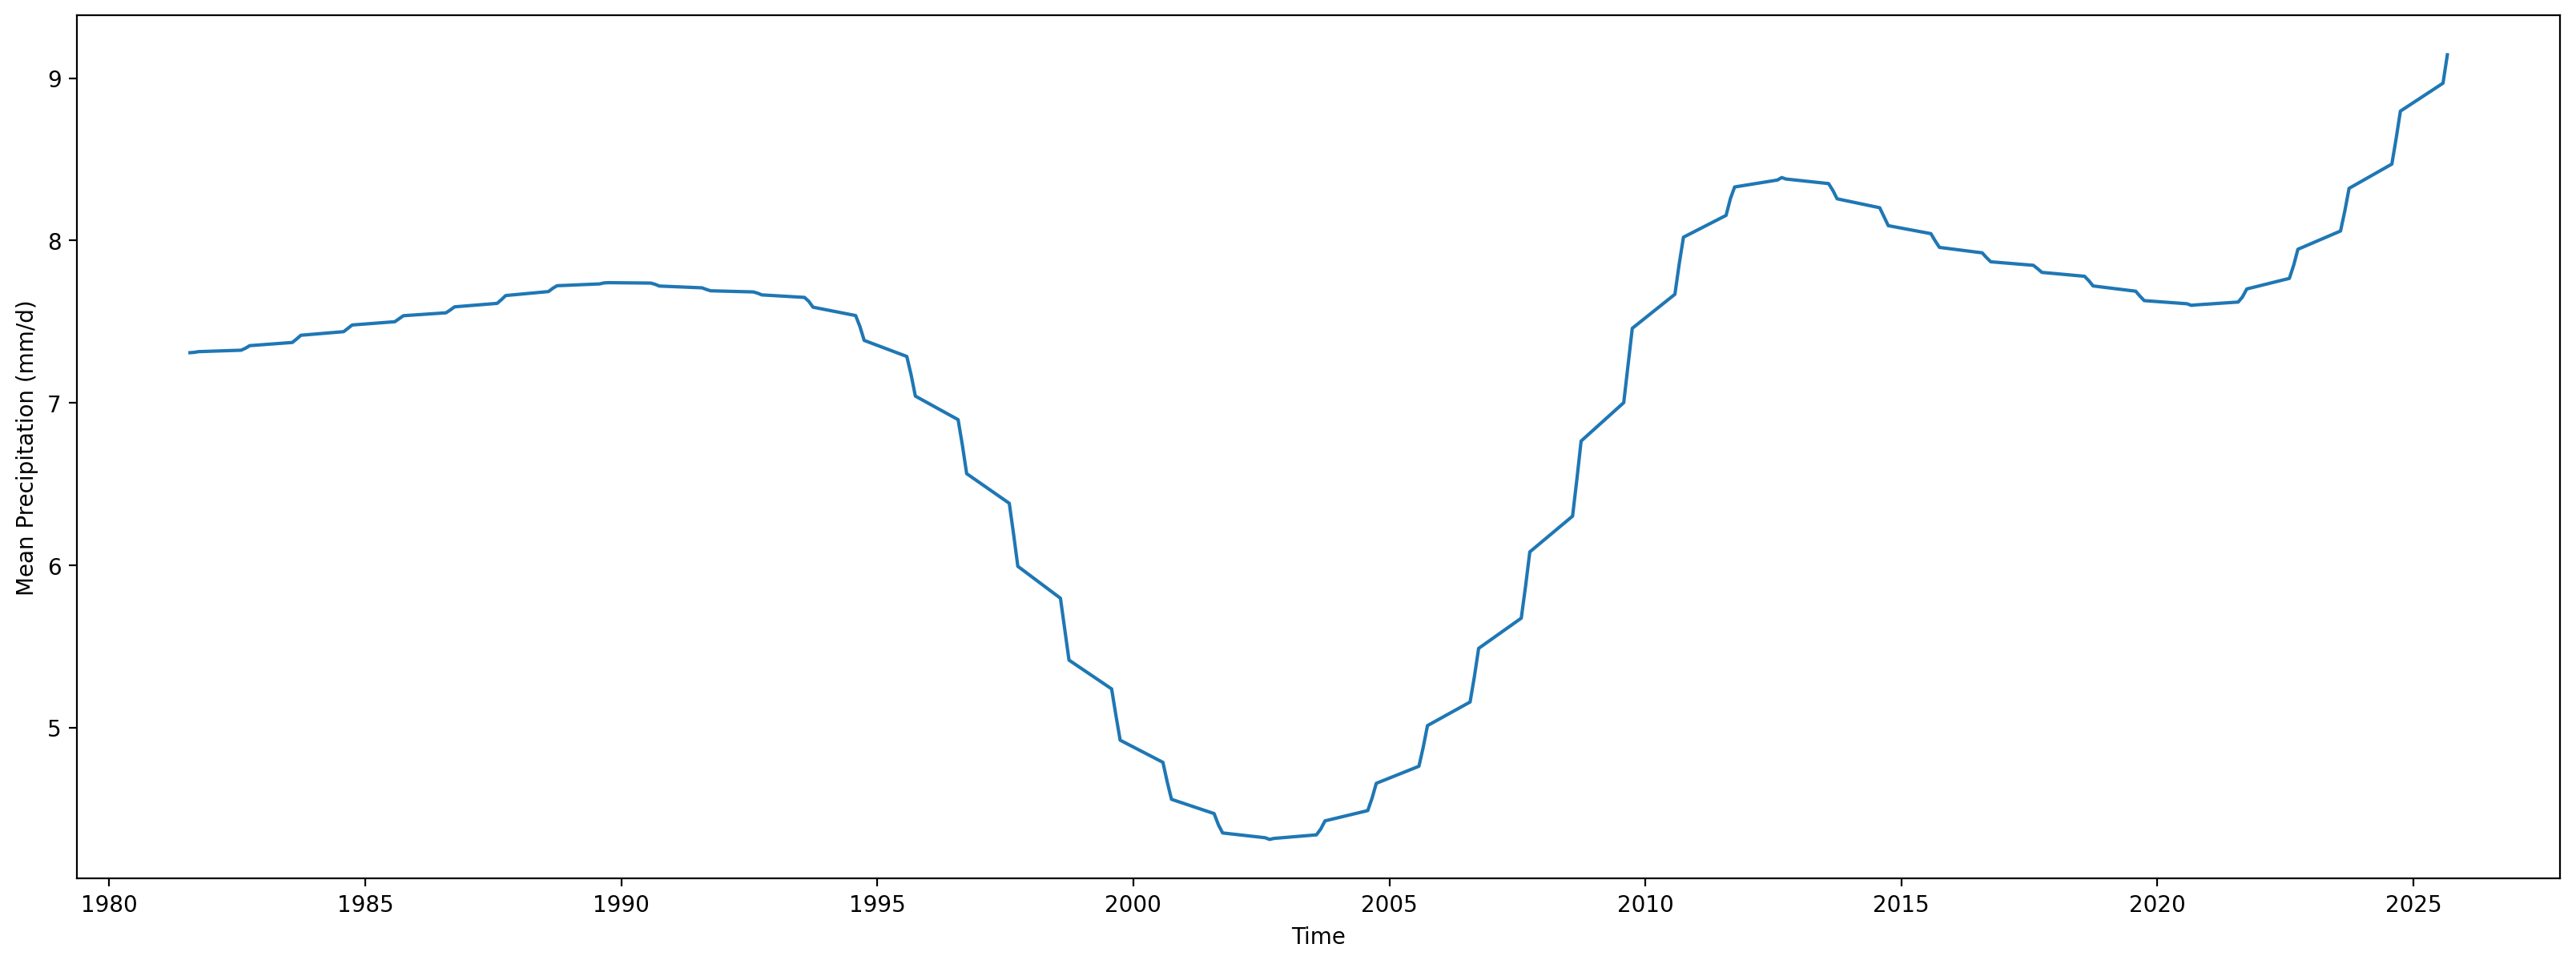

In [54]:
# seasonality_plot = px.line(x=months, y=rainfall_cycle, title="Seasonality")
# seasonality_plot.update_layout(
#     xaxis_title = "Time",
#     yaxis_title = "Mean Precipitation (mm/d)"
# )
# seasonality_plot.show()

# trend_plot = px.line(x=months, y=rainfall_trend, title="Trend")
# trend_plot.update_layout(
#     xaxis_title = "Time",
#     yaxis_title = "Mean Precipitation (mm/d)"
# )
# trend_plot.show()
plt.figure(figsize=(20, 7), dpi=200)
plt.plot(months, rainfall_trend, label="Trend")
plt.xlabel("Time")
plt.ylabel("Mean Precipitation (mm/d)")

## Performing Holt Exponential Smoothing

In [55]:
holt_smoothing = Holt(spatial_means).fit()
y_pred = holt_smoothing.predict(start=0, end=(len(spatial_means)-1))
px.line(x=months, y=y_pred)

In [56]:
arima = ARIMA(spatial_means).fit()
y_pred = arima.predict(start=0, end=(len(spatial_means)-1))
px.line(x=months, y=y_pred)